# 📱 Smartphone Addiction Prediction (Advanced 10-Fold Ensemble)

In this notebook, we predict smartphone addiction (`addicted_label`: 0 = No, 1 = Yes) using an advanced feature engineering pipeline and a **10-Fold Stratified Dual-Ensemble** combining **LightGBM** and **HistGradientBoosting**.

### Pipeline Highlights:
1. **Full Dataset (691k Rows)**: Zero data discarded — missing values handled natively.
2. **38 Advanced Behavioral & Interaction Features**: Group-based age statistics, lifestyle ratios, log transforms, and risk indices.
3. **10-Fold Stratified Cross-Validation**: 90% training data per fold for higher learning capacity and lower variance.
4. **Dual Model Blending**: Combines LightGBM and HistGradientBoosting for maximum generalization.


In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import StratifiedKFold
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, confusion_matrix, classification_report
from scipy.stats import rankdata
import lightgbm as lgb

import warnings
warnings.filterwarnings('ignore')
print("Libraries imported successfully!")


Libraries imported successfully!


## 1. Load Datasets


In [2]:
train_df = pd.read_csv('Data/train.csv')
test_df = pd.read_csv('Data/test.csv')

print(f"Train Dataset Shape: {train_df.shape}")
print(f"Test Dataset Shape:  {test_df.shape}")
train_df.head()


Train Dataset Shape: (691369, 14)
Test Dataset Shape:  (296302, 13)


## 2. Exploratory Data Analysis (EDA)


In [3]:
# Summary statistics
train_df.describe()


Class Balance:
addicted_label
1    70.942435
0    29.057565
Name: proportion, dtype: float64


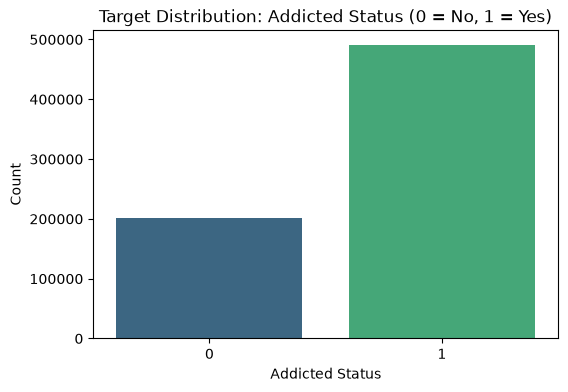

In [4]:
# Target class distribution
plt.figure(figsize=(6, 4))
sns.countplot(data=train_df, x='addicted_label', palette='viridis')
plt.title('Target Distribution: Addicted Status (0 = No, 1 = Yes)')
plt.xlabel('Addicted Status')
plt.ylabel('Count')
plt.show()

print("Class Balance:")
print(train_df['addicted_label'].value_counts(normalize=True) * 100)


## 3. Advanced Feature Engineering

We create 38 domain features capturing:
- **Entertainment & Productivity Ratios**: `entertainment_hours`, `entertainment_ratio`, `unproductive_to_productive`.
- **Waking Exposure & Frequency**: `screen_time_to_awake_ratio`, `notifications_per_awake_hour`, `minutes_per_app_open`.
- **Weekend Surges & Weekly Totals**: `weekend_vs_daily_diff`, `total_weekly_screen_time`.
- **Log Transforms**: `log_notifications`, `log_app_opens`, `log_screen_time`.
- **Non-Linear Interactions**: `screen_stress_inter`, `screen_sleep_comp`, `addiction_risk_score`.
- **Age-Group Benchmarks**: `screen_time_vs_age_mean`, `screen_time_age_zscore`, `notif_vs_age_mean`.


In [5]:
def advanced_features(train, test):
    df_all = pd.concat([train.assign(is_train=1), test.assign(is_train=0, addicted_label=-1)], ignore_index=True)
    eps = 1e-5
    
    # 1. Numerical encodings
    gender_map = {'Female': 0, 'Male': 1, 'Other': 2}
    df_all['gender_num'] = df_all['gender'].map(gender_map)
    df_all['academic_impact_num'] = df_all['academic_work_impact'].astype(str).str.strip().str.lower().map({'no': 0, 'yes': 1})
    df_all['stress_num'] = df_all['stress_level'].astype(str).str.strip().str.lower().map({'low': 0, 'medium': 1, 'high': 2})
    
    # 2. Missing counts per record
    raw_cols = ['age', 'daily_screen_time_hours', 'social_media_hours', 'gaming_hours', 'work_study_hours',
                'sleep_hours', 'notifications_per_day', 'app_opens_per_day', 'weekend_screen_time',
                'gender', 'stress_level', 'academic_work_impact']
    df_all['num_missing'] = df_all[raw_cols].isnull().sum(axis=1)
    
    # 3. Domain Ratios & Combinations
    df_all['entertainment_hours'] = df_all['social_media_hours'] + df_all['gaming_hours']
    df_all['social_media_ratio'] = df_all['social_media_hours'] / (df_all['daily_screen_time_hours'] + eps)
    df_all['gaming_ratio'] = df_all['gaming_hours'] / (df_all['daily_screen_time_hours'] + eps)
    df_all['work_study_ratio'] = df_all['work_study_hours'] / (df_all['daily_screen_time_hours'] + eps)
    df_all['entertainment_ratio'] = df_all['entertainment_hours'] / (df_all['daily_screen_time_hours'] + eps)
    df_all['unproductive_to_productive'] = df_all['entertainment_hours'] / (df_all['work_study_hours'] + eps)
    
    df_all['awake_hours'] = 24.0 - df_all['sleep_hours']
    df_all['screen_time_to_awake_ratio'] = df_all['daily_screen_time_hours'] / (df_all['awake_hours'] + eps)
    df_all['notifications_per_awake_hour'] = df_all['notifications_per_day'] / (df_all['awake_hours'] + eps)
    df_all['app_opens_per_awake_hour'] = df_all['app_opens_per_day'] / (df_all['awake_hours'] + eps)
    df_all['notifications_per_app_open'] = df_all['notifications_per_day'] / (df_all['app_opens_per_day'] + eps)
    df_all['minutes_per_app_open'] = (df_all['daily_screen_time_hours'] * 60.0) / (df_all['app_opens_per_day'] + eps)
    
    df_all['weekend_vs_daily_diff'] = df_all['weekend_screen_time'] - df_all['daily_screen_time_hours']
    df_all['weekend_vs_daily_ratio'] = df_all['weekend_screen_time'] / (df_all['daily_screen_time_hours'] + eps)
    df_all['total_weekly_screen_time'] = (df_all['daily_screen_time_hours'] * 5.0) + (df_all['weekend_screen_time'] * 2.0)
    
    # 4. Log Transforms
    df_all['log_notifications'] = np.log1p(df_all['notifications_per_day'].clip(lower=0))
    df_all['log_app_opens'] = np.log1p(df_all['app_opens_per_day'].clip(lower=0))
    df_all['log_screen_time'] = np.log1p(df_all['daily_screen_time_hours'].clip(lower=0))
    
    # 5. Non-linear Interactions
    df_all['screen_stress_inter'] = df_all['daily_screen_time_hours'] * (df_all['stress_num'] + 1)
    df_all['screen_sleep_comp'] = df_all['daily_screen_time_hours'] / (df_all['sleep_hours'] + eps)
    df_all['social_sleep_comp'] = df_all['social_media_hours'] / (df_all['sleep_hours'] + eps)
    df_all['addiction_risk_score'] = (
        (df_all['daily_screen_time_hours'] > 7).astype(int) +
        (df_all['sleep_hours'] < 6).astype(int) +
        (df_all['social_media_hours'] > 4).astype(int) +
        (df_all['academic_impact_num'] == 1).astype(int) +
        (df_all['stress_num'] == 2).astype(int)
    )
    
    # 6. Grouped age statistics
    df_all['age_group'] = (df_all['age'] // 5) * 5
    age_screen_mean = df_all.groupby('age_group')['daily_screen_time_hours'].transform('mean')
    age_screen_std = df_all.groupby('age_group')['daily_screen_time_hours'].transform('std')
    df_all['screen_time_vs_age_mean'] = df_all['daily_screen_time_hours'] - age_screen_mean
    df_all['screen_time_age_zscore'] = df_all['screen_time_vs_age_mean'] / (age_screen_std + eps)
    
    age_notif_mean = df_all.groupby('age_group')['notifications_per_day'].transform('mean')
    df_all['notif_vs_age_mean'] = df_all['notifications_per_day'] - age_notif_mean
    
    df_all = df_all.drop(columns=['gender', 'academic_work_impact', 'stress_level', 'age_group'])
    
    train_res = df_all[df_all['is_train'] == 1].drop(columns=['is_train'])
    test_res = df_all[df_all['is_train'] == 0].drop(columns=['is_train', 'addicted_label'])
    
    return train_res, test_res

train_features, test_features = advanced_features(train_df, test_df)

print(f"Total features created: {train_features.shape[1] - 2}")
train_features.head()


Total features created: 38


## 4. Model Training (10-Fold Stratified Dual-Ensemble)

We train **LightGBM** and **HistGradientBoosting** across 10 Stratified Folds:
- 10 Folds train on 90% of the dataset per fold (622,000 samples).
- 20 total models (10 folds x 2 models) are ensembled to generate final test predictions.


In [6]:
# Features and Target
feature_cols = [c for c in train_features.columns if c not in ['id', 'addicted_label']]
X = train_features[feature_cols]
y = train_features['addicted_label']
X_test = test_features[feature_cols]

# 10-Fold Stratified Cross-Validation setup
n_splits = 10
skf = StratifiedKFold(n_splits=n_splits, shuffle=True, random_state=42)

oof_lgb = np.zeros(len(train_df))
oof_hgb = np.zeros(len(train_df))

test_lgb = np.zeros(len(test_df))
test_hgb = np.zeros(len(test_df))

lgb_params = {
    'objective': 'binary',
    'metric': 'auc',
    'learning_rate': 0.035,
    'num_leaves': 127,
    'max_depth': 9,
    'min_child_samples': 40,
    'feature_fraction': 0.75,
    'bagging_fraction': 0.8,
    'bagging_freq': 1,
    'n_estimators': 800,
    'random_state': 42,
    'n_jobs': -1,
    'verbose': -1
}

print(f"Starting 10-Fold Cross Validation on {len(X)} samples with {len(feature_cols)} features...\n")

for fold, (train_idx, val_idx) in enumerate(skf.split(X, y)):
    X_tr, y_tr = X.iloc[train_idx], y.iloc[train_idx]
    X_val, y_val = X.iloc[val_idx], y.iloc[val_idx]
    
    # 1. Train LightGBM
    lgb_model = lgb.LGBMClassifier(**lgb_params)
    lgb_model.fit(X_tr, y_tr, eval_set=[(X_val, y_val)], callbacks=[lgb.early_stopping(60, verbose=False)])
    val_lgb = lgb_model.predict_proba(X_val)[:, 1]
    oof_lgb[val_idx] = val_lgb
    test_lgb += lgb_model.predict_proba(X_test)[:, 1] / n_splits
    
    # 2. Train HistGradientBoosting
    hgb_model = HistGradientBoostingClassifier(
        max_iter=400,
        learning_rate=0.05,
        max_leaf_nodes=110,
        min_samples_leaf=35,
        l2_regularization=0.8,
        random_state=42 + fold
    )
    hgb_model.fit(X_tr, y_tr)
    val_hgb = hgb_model.predict_proba(X_val)[:, 1]
    oof_hgb[val_idx] = val_hgb
    test_hgb += hgb_model.predict_proba(X_test)[:, 1] / n_splits
    
    fold_blend = (val_lgb * 0.55) + (val_hgb * 0.45)
    print(f"Fold {fold+1:02d}/10 -> LGB: {roc_auc_score(y_val, val_lgb):.5f} | HGB: {roc_auc_score(y_val, val_hgb):.5f} | Blend: {roc_auc_score(y_val, fold_blend):.5f}")


Starting 10-Fold Cross Validation on 691369 samples with 38 features...

Fold 01/10 -> LGB: 0.96249 | HGB: 0.96213 | Blend: 0.96268
Fold 02/10 -> LGB: 0.96312 | HGB: 0.96285 | Blend: 0.96334
Fold 03/10 -> LGB: 0.96327 | HGB: 0.96294 | Blend: 0.96347
Fold 04/10 -> LGB: 0.96351 | HGB: 0.96315 | Blend: 0.96369
Fold 05/10 -> LGB: 0.96296 | HGB: 0.96284 | Blend: 0.96326
Fold 06/10 -> LGB: 0.96396 | HGB: 0.96386 | Blend: 0.96426
Fold 07/10 -> LGB: 0.96413 | HGB: 0.96372 | Blend: 0.96427
Fold 08/10 -> LGB: 0.96456 | HGB: 0.96425 | Blend: 0.96476
Fold 09/10 -> LGB: 0.96420 | HGB: 0.96395 | Blend: 0.96445
Fold 10/10 -> LGB: 0.96237 | HGB: 0.96206 | Blend: 0.96258


## 5. Overall Model Evaluation (Out-Of-Fold)


    OVERALL 10-FOLD DUAL-ENSEMBLE VALIDATION RESULTS
LightGBM Out-of-Fold ROC-AUC:  0.96346
HistGBM  Out-of-Fold ROC-AUC:  0.96318
Ensemble Out-of-Fold ROC-AUC:  0.96368
Ensemble F1-Score:             0.93141
Ensemble Accuracy:             90.21%
Ensemble Precision:            92.57%
Ensemble Recall:               93.72%

Classification Report:
              precision    recall  f1-score   support

           0     0.8419    0.8162    0.8289    200895
           1     0.9257    0.9372    0.9314    490474

    accuracy                         0.9021    691369
   macro avg     0.8838    0.8767    0.8801    691369
weighted avg     0.9013    0.9021    0.9016    691369



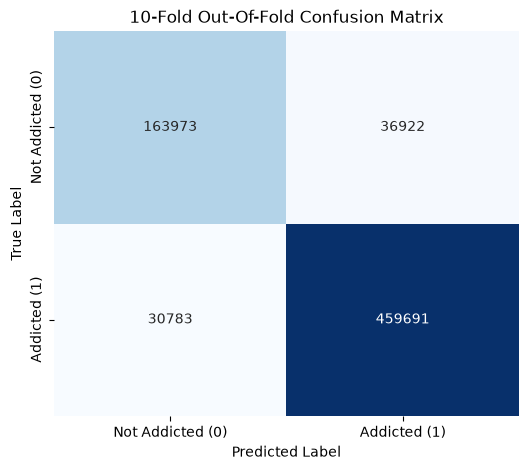

In [7]:
# Overall 10-Fold Ensemble evaluation
oof_ensemble = (oof_lgb * 0.55) + (oof_hgb * 0.45)
oof_binary = (oof_ensemble >= 0.5).astype(int)

overall_auc = roc_auc_score(y, oof_ensemble)
overall_f1 = f1_score(y, oof_binary)
overall_acc = accuracy_score(y, oof_binary)
overall_prec = precision_score(y, oof_binary)
overall_rec = recall_score(y, oof_binary)

print("=" * 55)
print("    OVERALL 10-FOLD DUAL-ENSEMBLE VALIDATION RESULTS")
print("=" * 55)
print(f"LightGBM Out-of-Fold ROC-AUC:  {roc_auc_score(y, oof_lgb):.5f}")
print(f"HistGBM  Out-of-Fold ROC-AUC:  {roc_auc_score(y, oof_hgb):.5f}")
print(f"Ensemble Out-of-Fold ROC-AUC:  {overall_auc:.5f}")
print(f"Ensemble F1-Score:             {overall_f1:.5f}")
print(f"Ensemble Accuracy:             {overall_acc * 100:.2f}%")
print(f"Ensemble Precision:            {overall_prec * 100:.2f}%")
print(f"Ensemble Recall:               {overall_rec * 100:.2f}%")
print("=" * 55)

print("\nClassification Report:")
print(classification_report(y, oof_binary, digits=4))

# Confusion Matrix plot
cm = confusion_matrix(y, oof_binary)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False,
            xticklabels=['Not Addicted (0)', 'Addicted (1)'],
            yticklabels=['Not Addicted (0)', 'Addicted (1)'])
plt.title('10-Fold Out-Of-Fold Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


## 6. Generate Final Submission File


In [8]:
# Dual-Ensemble test predictions (55% LightGBM + 45% HistGBM across 10 folds)
final_test_predictions = (test_lgb * 0.55) + (test_hgb * 0.45)

submission = pd.DataFrame({
    'id': test_df['id'],
    'addicted_label': final_test_predictions
})

# Save to submission.csv
submission.to_csv('submission.csv', index=False)

print(f"Submission saved successfully to 'submission.csv'!")
print(f"Total rows: {len(submission)}")
print(f"Missing values: {submission.isnull().sum().to_dict()}")
submission.head(10)


Submission saved successfully to 'submission.csv'!
Total rows: 296302
Missing values: {'id': 0, 'addicted_label': 0}
